# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click !here goes the icon of the corresponding button in the gutter! button.
To debug a cell, press Alt+Shift+Enter, or click !here goes the icon of the corresponding button in the gutter! button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/jupyter-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

       Method  Slope (ns/field)  Intercept (ns)  R_squared
0     ForLoop        224.704059     5762.267519   0.997302
1  LinqSelect        220.082271     5010.917905   0.991882


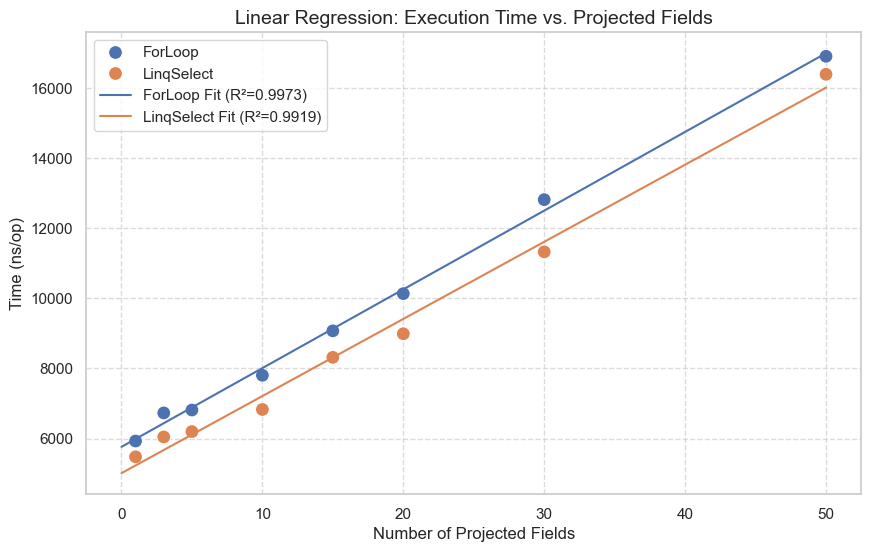

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load data
df = pd.read_csv('data/projection_performance_data.csv')
df['ProjectedFieldCount'] = df['Params'].str.extract(r'ProjectedFieldCount=(\d+)').astype(int)

# Filter for the actual workload results
df_filtered = df[(df['Measurement_IterationMode'] == 'Workload') & (df['Measurement_IterationStage'] == 'Result')]

# Aggregate to get means for each Method and Parameter combination
summary = df_filtered.groupby(['Target_Method', 'ProjectedFieldCount'])['Measurement_Value'].mean().reset_index()

# Initialize plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary, x='ProjectedFieldCount', y='Measurement_Value', hue='Target_Method', s=100)

regression_results = []

methods = summary['Target_Method'].unique()
colors = sns.color_range = sns.color_palette(n_colors=len(methods))

for i, method in enumerate(methods):
    method_data = summary[summary['Target_Method'] == method]
    X = method_data['ProjectedFieldCount'].values.reshape(-1, 1)
    y = method_data['Measurement_Value'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    slope = model.coef_[0]
    intercept = model.intercept_
    r_squared = model.score(X, y)
    
    regression_results.append({
        'Method': method,
        'Slope (ns/field)': slope,
        'Intercept (ns)': intercept,
        'R_squared': r_squared
    })
    
    # Plot regression line
    x_range = np.linspace(0, 50, 100).reshape(-1, 1)
    y_pred = model.predict(x_range)
    plt.plot(x_range, y_pred, color=colors[i], label=f'{method} Fit (R²={r_squared:.4f})')

plt.title('Linear Regression: Execution Time vs. Projected Fields', fontsize=14)
plt.xlabel('Number of Projected Fields')
plt.ylabel('Time (ns/op)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('images/projection_regression_analysis.png')

results_df = pd.DataFrame(regression_results)
print(results_df)